# Airline Delay Data Pipeline

Dataset taken from kaggle: https://www.kaggle.com/datasets/sriharshaeedala/airline-delay/data

ETL + some visualizations for the project

In [5]:
#importing required libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1 - Loading the data

In [6]:
df_raw = pd.read_csv('airline_delay.csv')
print(df_raw.shape)
df_raw.head()

(171666, 21)


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [35]:
#Quick look on datatypes and no of absent data
print(df_raw.dtypes)
print()
print(df_raw.isnull().sum())

year                     int64
month                    int64
carrier                 object
carrier_name            object
airport                 object
airport_name            object
arr_flights            float64
arr_del15              float64
carrier_ct             float64
weather_ct             float64
nas_ct                 float64
security_ct            float64
late_aircraft_ct       float64
arr_cancelled          float64
arr_diverted           float64
arr_delay              float64
carrier_delay          float64
weather_delay          float64
nas_delay              float64
security_delay         float64
late_aircraft_delay    float64
dtype: object

year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights            240
arr_del15              443
carrier_ct             240
weather_ct             240
nas_ct                 240
security_ct            240
late_aircr

In [36]:
df_raw.describe()

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,171666.000000,171666.000000,171426.000000,171223.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.00000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000
mean,2018.551361,6.493633,362.528467,66.434387,20.796615,2.250347,19.381147,0.157096,23.770554,7.530497,0.863387,4239.48733,1437.185124,222.563497,920.651704,7.382725,1651.700063
std,2.890006,3.440908,992.894662,179.540694,50.315176,7.314252,61.675244,0.717405,72.393477,43.654880,3.772853,12618.56605,4215.677812,821.086511,3423.509335,41.779985,5221.878385
min,2013.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016.000000,4.000000,50.000000,6.000000,2.160000,0.000000,1.000000,0.000000,1.230000,0.000000,0.000000,335.00000,110.000000,0.000000,34.000000,0.000000,65.000000
50%,2019.000000,7.000000,100.000000,17.000000,6.400000,0.400000,3.910000,0.000000,5.000000,1.000000,0.000000,1018.00000,375.000000,18.000000,146.000000,0.000000,320.000000
75%,2021.000000,9.000000,250.000000,47.000000,17.260000,1.860000,11.710000,0.000000,15.260000,4.000000,1.000000,2884.00000,1109.000000,146.000000,477.000000,0.000000,1070.000000
max,2023.000000,12.000000,21977.000000,4176.000000,1293.910000,266.420000,1884.420000,58.690000,2069.070000,4951.000000,197.000000,438783.00000,196944.000000,31960.000000,112018.000000,3760.000000,227959.000000


## Step 2 - Cleaning / Transforms

In [37]:
df = df_raw.copy()

# fixing column names - lowercase, replace spaces with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_', regex=False).str.replace(r'[^\w]', '_', regex=True)
print(df.columns.tolist())

['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name', 'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']


In [38]:
# filling missing values
# using median for numbers and mode for strings

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print('missing values remaining:', df.isnull().sum().sum())

missing values remaining: 0


In [39]:
# dropping duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f'dropped {before - len(df)} rows, {len(df)} left')

dropped 0 rows, 171666 left


In [40]:
# making sure year/month are integers and delay and arr columns are numeric
for col in ['year', 'month']:
    if col in df.columns:
        df[col] = df[col].astype(int)

delay_cols = [c for c in df.columns if 'delay' in c or 'arr' in c ]
for col in delay_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print(delay_cols)

['carrier', 'carrier_name', 'arr_flights', 'arr_del15', 'carrier_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']


In [41]:
# feature engineering

# sum up all delay components into one column
component_cols = [c for c in df.columns if c in [
    'carrier_delay', 'weather_delay', 'nas_delay',
    'security_delay', 'late_aircraft_delay'
]]

if component_cols:
    df['total_delay'] = df[component_cols].sum(axis=1)

if 'arr_delay' in df.columns:
    df['on_time'] = (df['arr_delay'] <= 0).astype(int)
    print(f'on-time rate: {df["on_time"].mean()*100:.1f}%')

if 'arr_delay' in df.columns:
    bins = [-np.inf, 0, 15, 45, 120, np.inf]
    labels = ['On Time', 'Minor', 'Moderate', 'Severe', 'Very Severe']
    df['delay_category'] = pd.cut(df['arr_delay'], bins=bins, labels=labels)

on-time rate: 4.0%


In [42]:
df.shape

(171666, 24)

In [43]:
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,total_delay,on_time,delay_category
0,2023,8,0.0,0.0,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,1.0,1375.0,71.0,761.0,118.0,0.0,425.0,1375.0,0,Very Severe
1,2023,8,0.0,0.0,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,1.0,799.0,218.0,1.0,62.0,0.0,518.0,799.0,0,Very Severe
2,2023,8,0.0,0.0,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,766.0,56.0,188.0,78.0,0.0,444.0,766.0,0,Very Severe
3,2023,8,0.0,0.0,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,1.0,1397.0,471.0,320.0,388.0,0.0,218.0,1397.0,0,Very Severe
4,2023,8,0.0,0.0,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,1530.0,628.0,0.0,134.0,0.0,768.0,1530.0,0,Very Severe


## Step 3 - Save cleaned data

In [44]:
df.to_csv('airline_delay_cleaned.csv', index=False)
print('saved!')

saved!


## Step 4 - Visualizations

doing correlation heatmap, distributions, and a few seaborn plots

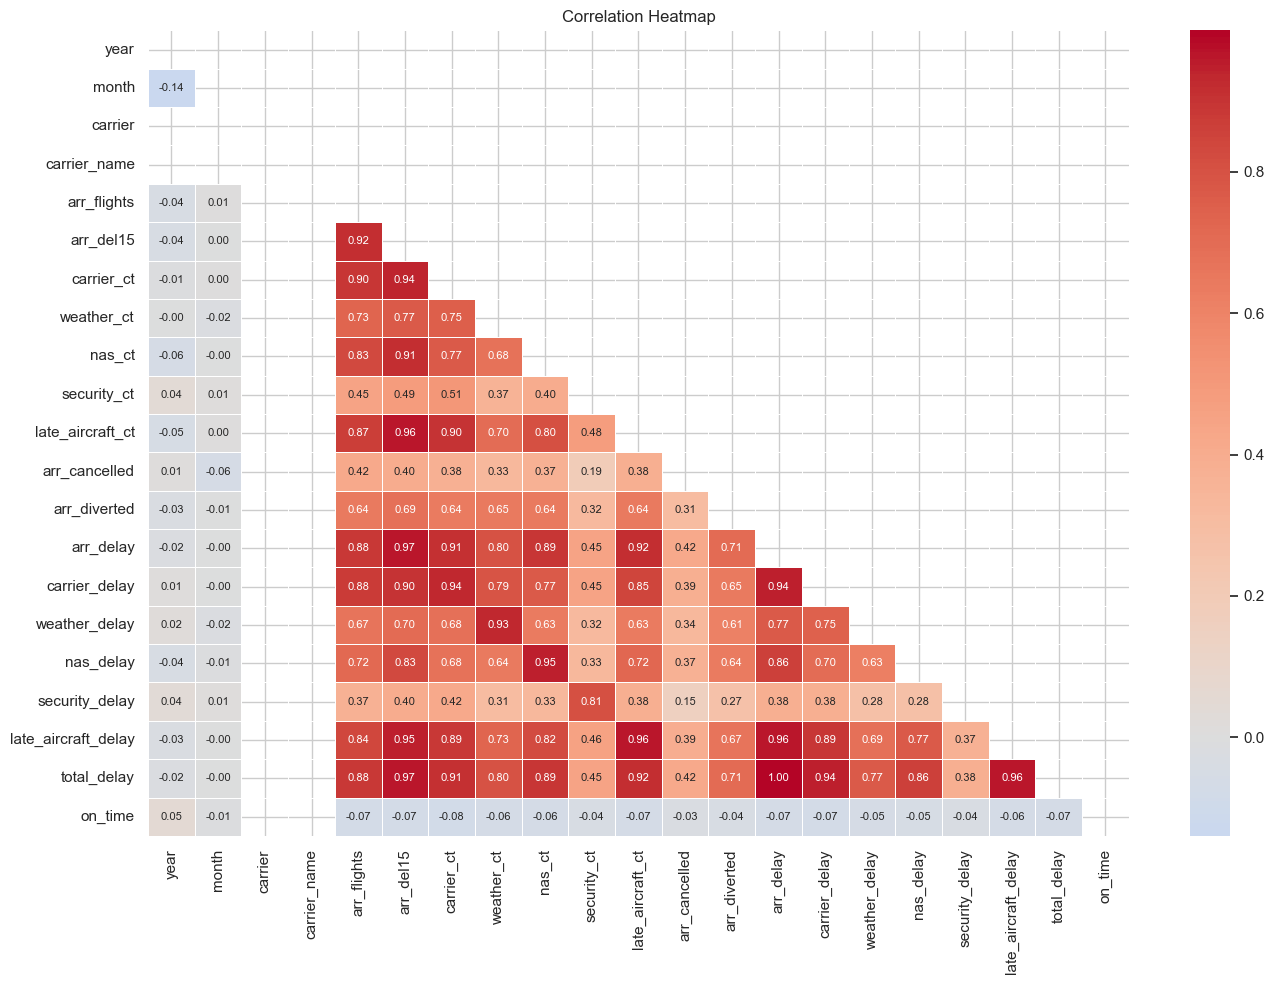

In [45]:
# correlation heatmap
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

# mask upper triangle so it's not redundant
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('viz_01_correlation_heatmap.png', dpi=150)
plt.show()

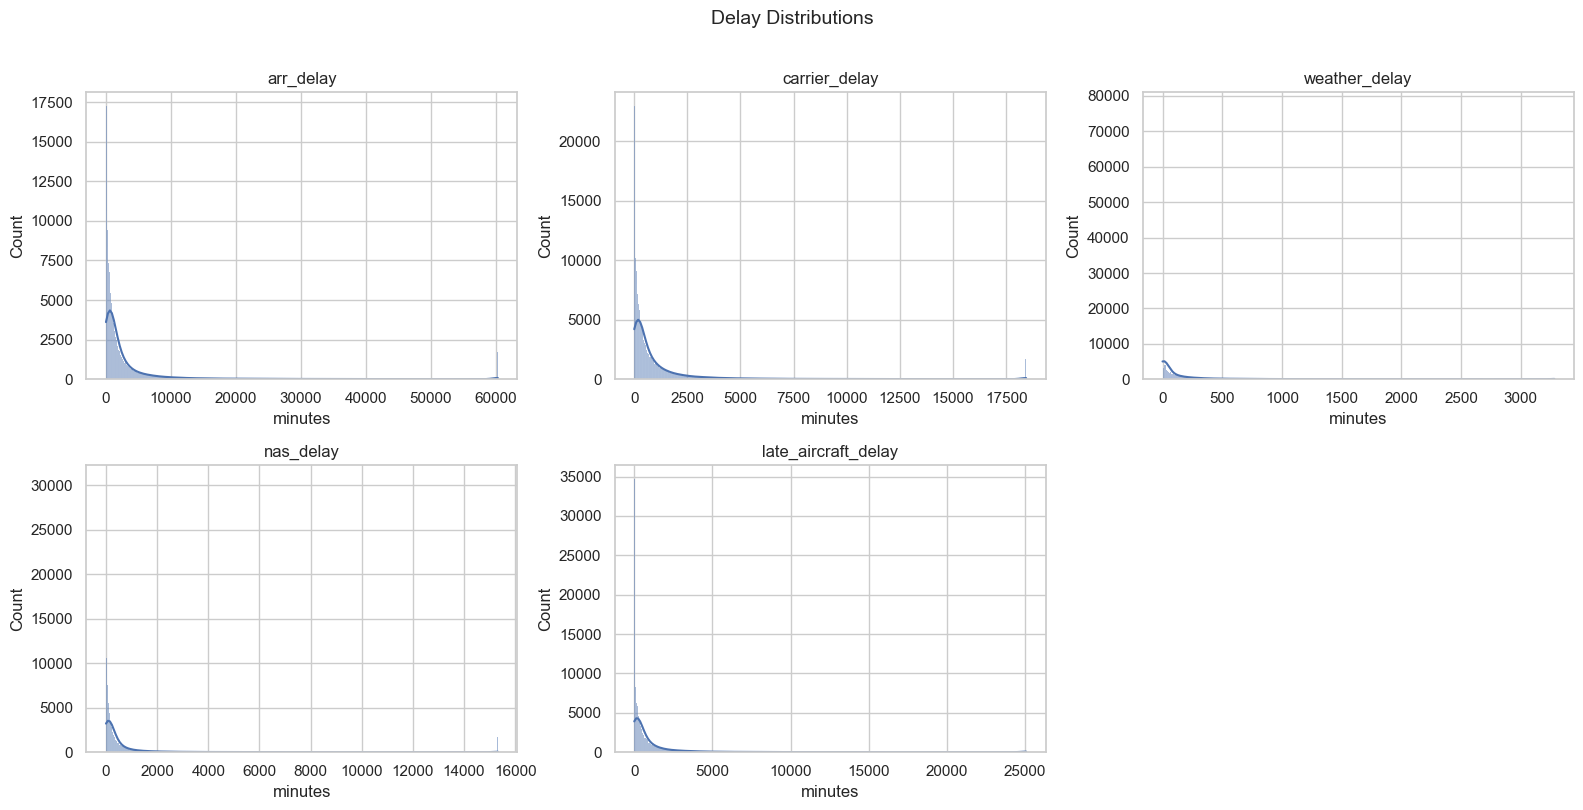

In [46]:
# distributions for the main delay columns
dist_cols = [c for c in [
    'arr_delay', 'dep_delay', 'carrier_delay',
    'weather_delay', 'nas_delay', 'late_aircraft_delay'
] if c in df.columns][:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(dist_cols):
    # clipping the top 1% otherwise the histograms look terrible
    data = df[col].clip(upper=df[col].quantile(0.99))
    sns.histplot(data, kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('minutes')

for j in range(len(dist_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Delay Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('viz_02_distributions.png', dpi=150)
plt.show()

In [47]:
# avg arrival delay per airline
# need to find which column has the carrier names
carrier_col = next((c for c in df.columns if 'carrier' in c and df[c].dtype == object), None)

if carrier_col and 'arr_delay' in df.columns:
    top_carriers = (
        df.groupby(carrier_col)['arr_delay']
        .mean()
        .sort_values(ascending=False)
        .head(15)
        .reset_index()
    )

    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_carriers, x=carrier_col, y='arr_delay', palette='rocket')
    plt.title('Average Arrival Delay by Carrier (top 15)')
    plt.xlabel('Carrier')
    plt.ylabel('Avg Delay (min)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('viz_03_carrier_delay_bar.png', dpi=150)
    plt.show()
else:
    print('could not find carrier column, skipping')

could not find carrier column, skipping


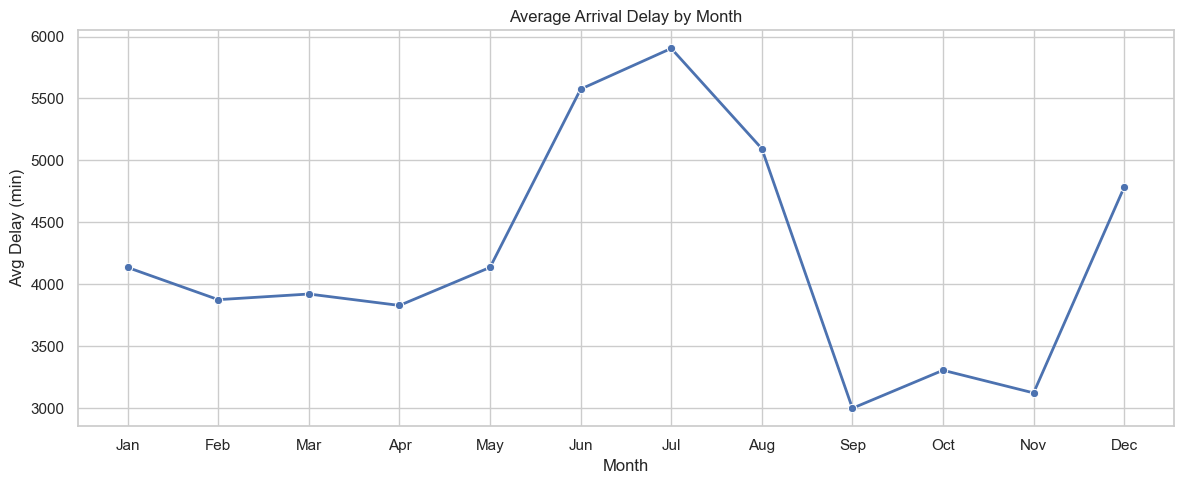

In [48]:
# delay by month - want to see if summer is actually worse
if 'month' in df.columns and 'arr_delay' in df.columns:
    monthly = df.groupby('month')['arr_delay'].mean().reset_index()

    month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                   7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
    monthly['month_name'] = monthly['month'].map(month_names)

    plt.figure(figsize=(12, 5))
    sns.lineplot(data=monthly, x='month', y='arr_delay', marker='o', linewidth=2)
    plt.xticks(ticks=monthly['month'], labels=monthly['month_name'])
    plt.title('Average Arrival Delay by Month')
    plt.xlabel('Month')
    plt.ylabel('Avg Delay (min)')
    plt.tight_layout()
    plt.savefig('viz_04_monthly_trend.png', dpi=150)
    plt.show()

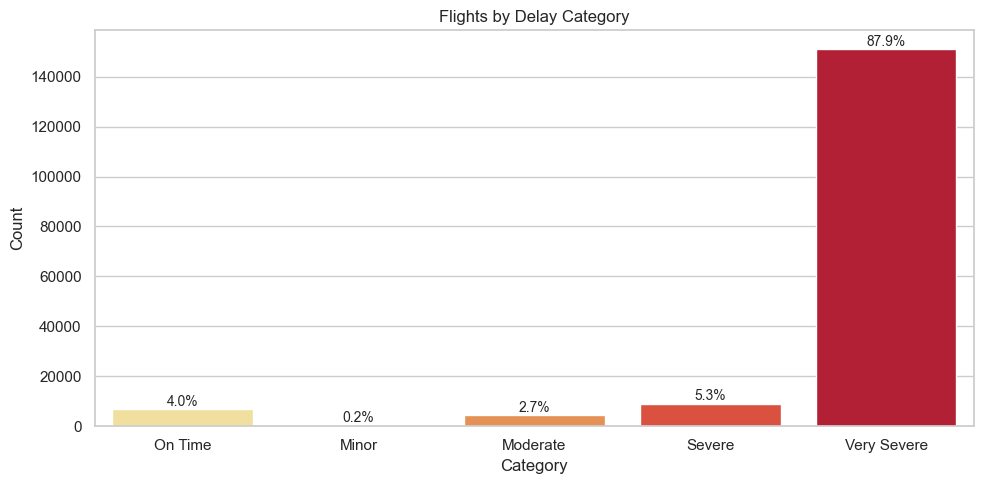

In [49]:
# how many flights fall into each delay bucket
if 'delay_category' in df.columns:
    order = ['On Time', 'Minor', 'Moderate', 'Severe', 'Very Severe']

    plt.figure(figsize=(10, 5))
    ax = sns.countplot(data=df, x='delay_category', order=order, palette='YlOrRd')

    # adding percentage labels on bars
    total = len(df)
    for p in ax.patches:
        pct = f'{100 * p.get_height() / total:.1f}%'
        ax.annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height() + 50),
                    ha='center', va='bottom', fontsize=10)

    plt.title('Flights by Delay Category')
    plt.xlabel('Category')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig('viz_05_delay_categories.png', dpi=150)
    plt.show()

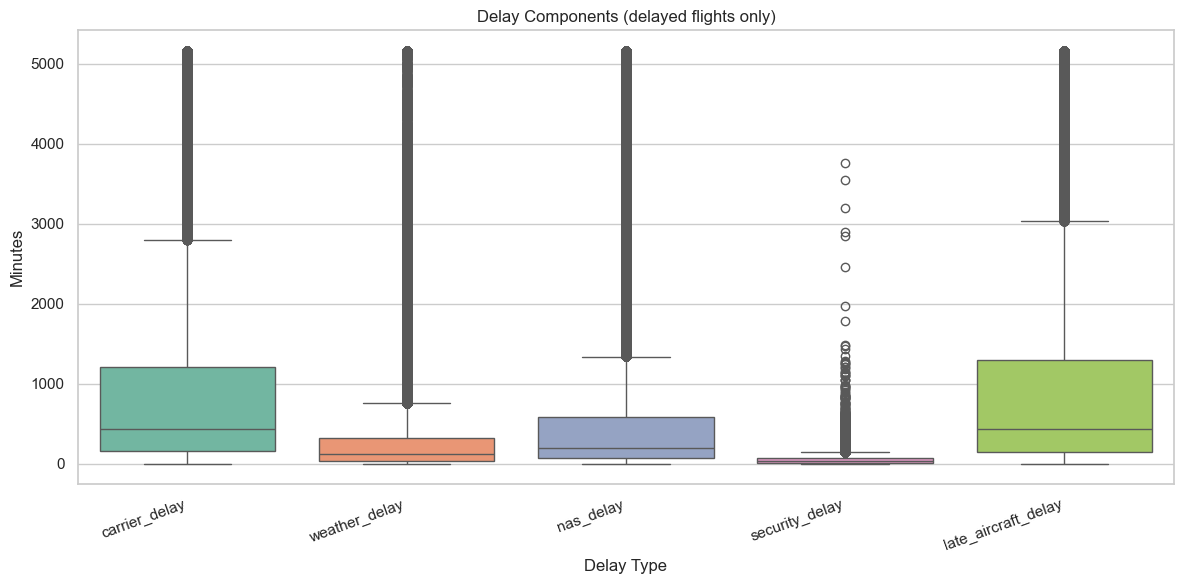

In [50]:
# boxplot comparing the different types of delays
# only looking at flights that actually had a delay (>0)

box_cols = [c for c in [
    'carrier_delay', 'weather_delay', 'nas_delay',
    'security_delay', 'late_aircraft_delay'
] if c in df.columns]

if box_cols:
    melted = df[box_cols].melt(var_name='delay_type', value_name='minutes')
    melted = melted[melted['minutes'] > 0]
    melted['minutes'] = melted['minutes'].clip(upper=melted['minutes'].quantile(0.95))

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=melted, x='delay_type', y='minutes', palette='Set2')
    plt.title('Delay Components (delayed flights only)')
    plt.xlabel('Delay Type')
    plt.ylabel('Minutes')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.savefig('viz_06_delay_components_boxplot.png', dpi=150)
    plt.show()

## Step 5 - Findings

- most flights are actually on time, the distributions are really skewed right i.e.a small number of bad delays are pulling the average up a lot
- late aircraft and carrier delays are the biggest contributors, weather is less common but can be really extreme
- summer months (june-aug) have noticeably higher delays, probably due to thunderstorms and more traffic
- there's a pretty big spread between airlines i.e. some are consistently worse than others
- delay types are correlated with each other i.e. makes sense because a late arriving plane causes a late departure which causes more delays downstream
- security delay is almost negligible compared to the rest

In [51]:
print('done')
print(f'raw: {df_raw.shape[0]} rows')
print(f'cleaned: {df.shape[0]} rows, {df.shape[1]} columns')

done
raw: 171666 rows
cleaned: 171666 rows, 24 columns
